Foauda dp a90d 9f. 
fas

Dynamic programming matrix initialized:
    A T G C T 
  0 0 0 0 0 0 
A 0 0 0 0 0 0 
G 0 0 0 0 0 0 
C 0 0 0 0 0 0 
T 0 0 0 0 0 0 
After filling the M matrix:
    A T G C T 
  0 0 0 0 0 0 
A 0 1 0 0 0 0 
G 0 0 0 1 0 0 
C 0 0 0 0 2 0 
T 0 0 1 0 0 3 
The distance between AGCT and ATGCT is: 3
The CIGAR string is: MMM
Backtrace path: [(2, 3), (3, 4), (4, 5)]


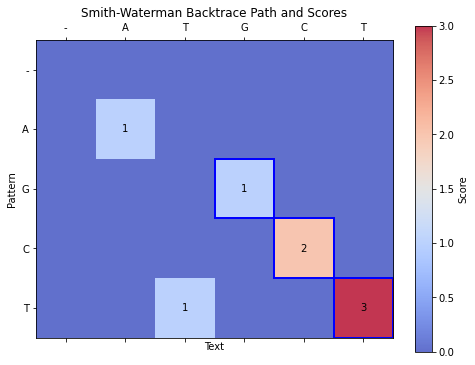

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Function to print the DP matrix
def pprint_matrix(M, pattern, text):
    try:
        if (len(pattern) + 1 != len(M)) or (len(text) + 1 != len(M[0])):
            raise Exception('Invalid matrix dimensions')
        # Print the header row
        print('    ', end='')
        for idx in range(len(text)):
            print(text[idx], end=' ')
        print()

        # Print each row
        for ridx, row in enumerate(M):
            for cidx in range(len(row)):
                if cidx == 0:
                    # Print the pattern character for the row
                    print(' ' if ridx == 0 else pattern[ridx - 1], end=' ')
                print(M[ridx][cidx], end=' ')
            print()
    except Exception as e:
        print(f'Invalid dynamic programming matrix! Are you sure you are creating the matrix with the correct dimensions?')
        raise e

# Function to backtrace the alignment and compute the CIGAR string
def traceback(M, pattern, text, max_position):
    i, j = max_position
    cigar = []
    backtrace_path = []  # Store the backtrace path for visualization

    while i > 0 and j > 0 and M[i][j] > 0:
        backtrace_path.append((i, j))  # Add current position to path
        if M[i][j] == M[i-1][j-1] + (1 if pattern[i-1] == text[j-1] else -1):
            cigar.append("M")  # Match/Mismatch
            i -= 1
            j -= 1
        elif M[i][j] == M[i][j-1] - 2:
            cigar.append("I")  # Insertion
            j -= 1
        elif M[i][j] == M[i-1][j] - 2:
            cigar.append("D")  # Deletion
            i -= 1

    cigar.reverse()
    backtrace_path.reverse()  # Reverse to start from the first match
    return M[max_position[0]][max_position[1]], "".join(cigar), backtrace_path

# Function to compute the Smith-Waterman DP matrix and backtrace
def smith_waterman_dp(pattern, text):
    m = len(pattern)
    n = len(text)
    M = [[0] * (n + 1) for _ in range(m + 1)]

    print('Dynamic programming matrix initialized:')
    pprint_matrix(M, pattern, text)

    max_score = 0
    max_position = (0, 0)

    # Fill the DP matrix
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if pattern[i-1] == text[j-1]:
                score = 1  # Match
            else:
                score = -1  # Mismatch

            diagonal = M[i-1][j-1] + score  # Match or mismatch
            insertion = M[i][j-1] - 2       # Insertion penalty
            deletion = M[i-1][j] - 2        # Deletion penalty

            M[i][j] = max(diagonal, insertion, deletion, 0)  # Use 0 for local alignment

            if M[i][j] > max_score:
                max_score = M[i][j]
                max_position = (i, j)

    print('After filling the M matrix:')
    pprint_matrix(M, pattern, text)

    distance, cigar, backtrace_path = traceback(M, pattern, text, max_position)
    return M, (distance, cigar, backtrace_path)

# Function to visualize the Smith-Waterman DP matrix
def visualize_smith_waterman(M, pattern, text, backtrace_path):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Overlay the matrix with a heatmap
    cax = ax.matshow(M, cmap="coolwarm", alpha=0.8)
    plt.colorbar(cax, label="Score")

    # Annotate non-zero cells with values
    for i in range(len(pattern) + 1):
        for j in range(len(text) + 1):
            if M[i][j] > 0:
                ax.text(j, i, str(M[i][j]), ha='center', va='center', color='black', fontsize=10)

    # Highlight the backtrace path with blue rectangles
    for (i, j) in backtrace_path:
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, edgecolor='blue', fill=False, linewidth=2)
        ax.add_patch(rect)

    # Set axis labels
    ax.set_xticks(np.arange(len(text) + 1))
    ax.set_yticks(np.arange(len(pattern) + 1))
    ax.set_xticklabels(['-'] + list(text))
    ax.set_yticklabels(['-'] + list(pattern))

    # Set title and labels
    plt.title("Smith-Waterman Backtrace Path and Scores")
    plt.xlabel("Text")
    plt.ylabel("Pattern")
    plt.show()

# Main script
if __name__ == "__main__":
    pattern = 'AGCT'
    text = 'ATGCT'

    # Compute the DP matrix and backtrace
    M, (distance, cigar, backtrace_path) = smith_waterman_dp(pattern, text)

    print(f'The distance between {pattern} and {text} is: {distance}')
    print(f'The CIGAR string is: {cigar}')
    print(f'Backtrace path: {backtrace_path}')

    # Visualize the DP matrix and the backtrace path
    visualize_smith_waterman(M, pattern, text, backtrace_path)
